### Neural networks

### 1. Revisiting models

Previously, we learns different prediction functions like

- linear regression
- logistic regression
- decision tree

etc.

These function maybe a simple formula like `f(x) = mx + c` for one-dimension linear regression, it may also be a sophisticated series of logic flow like the decision tree.

However they share the same idea: take an input, then return an output.

**Number of variables**

- Simple Linear regression: 2
- Simple Logistic regression: 2

*Model fitting*: During training stage, we use training data to find the optimal value of there variables.

### 2. Steps towards the actualy NN

**Brainstorming Exercise (OR case)**

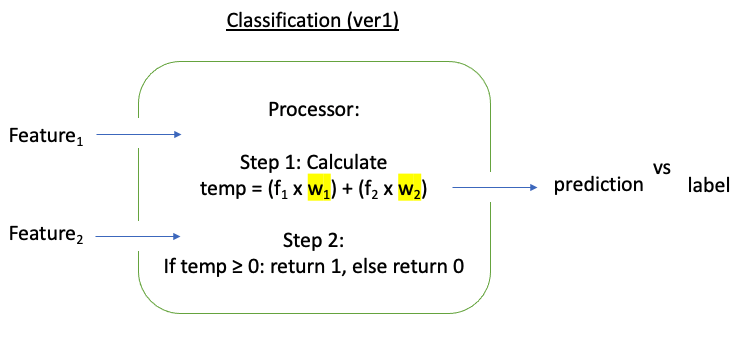

| feature 1     | feature 2     | label |
|:-------------:|:-------------:|:-----:|
|     1         |       1       |   1   |
|     1         |       -1       |   1   |
|     -1         |       1       |   1   |
|     -1         |       -1       |   0   |

Looks familiar? Yes, we are trying to use an arithmetic method to reprecate the "OR" function.

Question: What should be put for w1 and w2?

In [ ]:
samples = [
    [1, 1],
    [1, -1],
    [-1, 1],
    [-1, -1]
]

w0 = ?
w1 = ?

for a_sample in samples:

    temp = a_sample[0] * w0 + a_sample[1] * w1

    if temp >= 0:
        print(f"When A={a_sample[0]:>2}, B={a_sample[1]:>2}, Prediction:", 1)
    else:
        print(f"When A={a_sample[0]:>2}, B={a_sample[1]:>2}, Prediction:", 0)

**Brainstorming Exercise (AND case)**


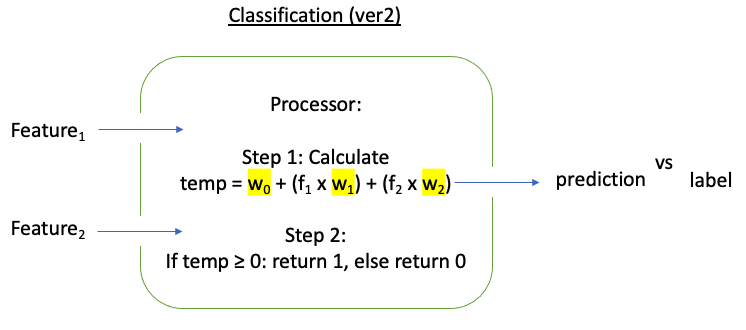

| feature 1     | feature 2     | label |
|:-------------:|:-------------:|:-----:|
|     1         |       1       |   1   |
|     1         |       -1       |   0   |
|     -1         |       1       |   0   |
|     -1         |       -1       |   0   |

Looks familiar? Yes, we are trying to use an arithmetic method to reprecate the "AND" function.  Different from the first example, we have one more variable to tune - w3, try to make use of it!

Question: What should be put for w0, w1 and w2?

In [ ]:
samples = [
    [1, 1],
    [1, -1],
    [-1, 1],
    [-1, -1]
]

w0 = ?
w1 = ?
w2 = ?

for a_sample in samples:

    temp = w0 + a_sample[0] * w1 + a_sample[1] * w2

    if temp >= 0:
        print(f"When A={a_sample[0]:>2}, B={a_sample[1]:>2}, Prediction:", 1)
    else:
        print(f"When A={a_sample[0]:>2}, B={a_sample[1]:>2}, Prediction:", 0)

**A little consolidation**

In the context of machine learning, we often refer
- w1 and w2 be "weights"
- w0 be "bias".
- step 2 be "activation"



*`What is the similarity and difference between neural network and linear regression?`*

### 3. Single Layer neural network (perceptron)

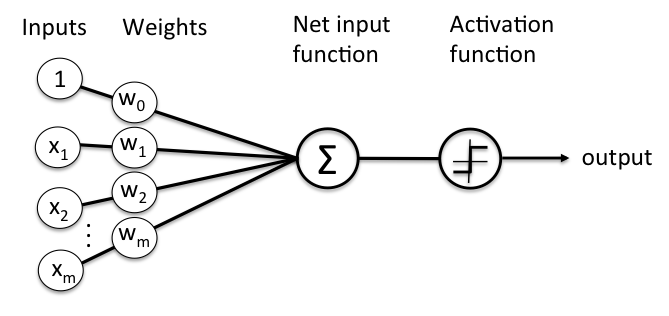

A single layer of percetron contains the following:

1. An input vector
2. A set of weights
3. An activation function
4. A binary output

**Activation function**

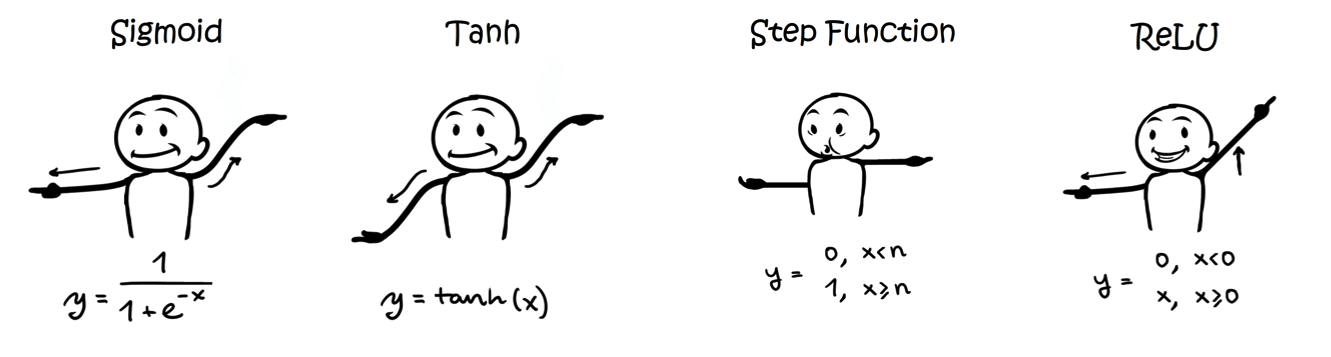

We have already visited one of the activation function.  Here's other common ones.  Fill in the missing piece and run the code and look at each of the diagram to see the difference.

<ipython-input-3-b3c7940170f2>:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


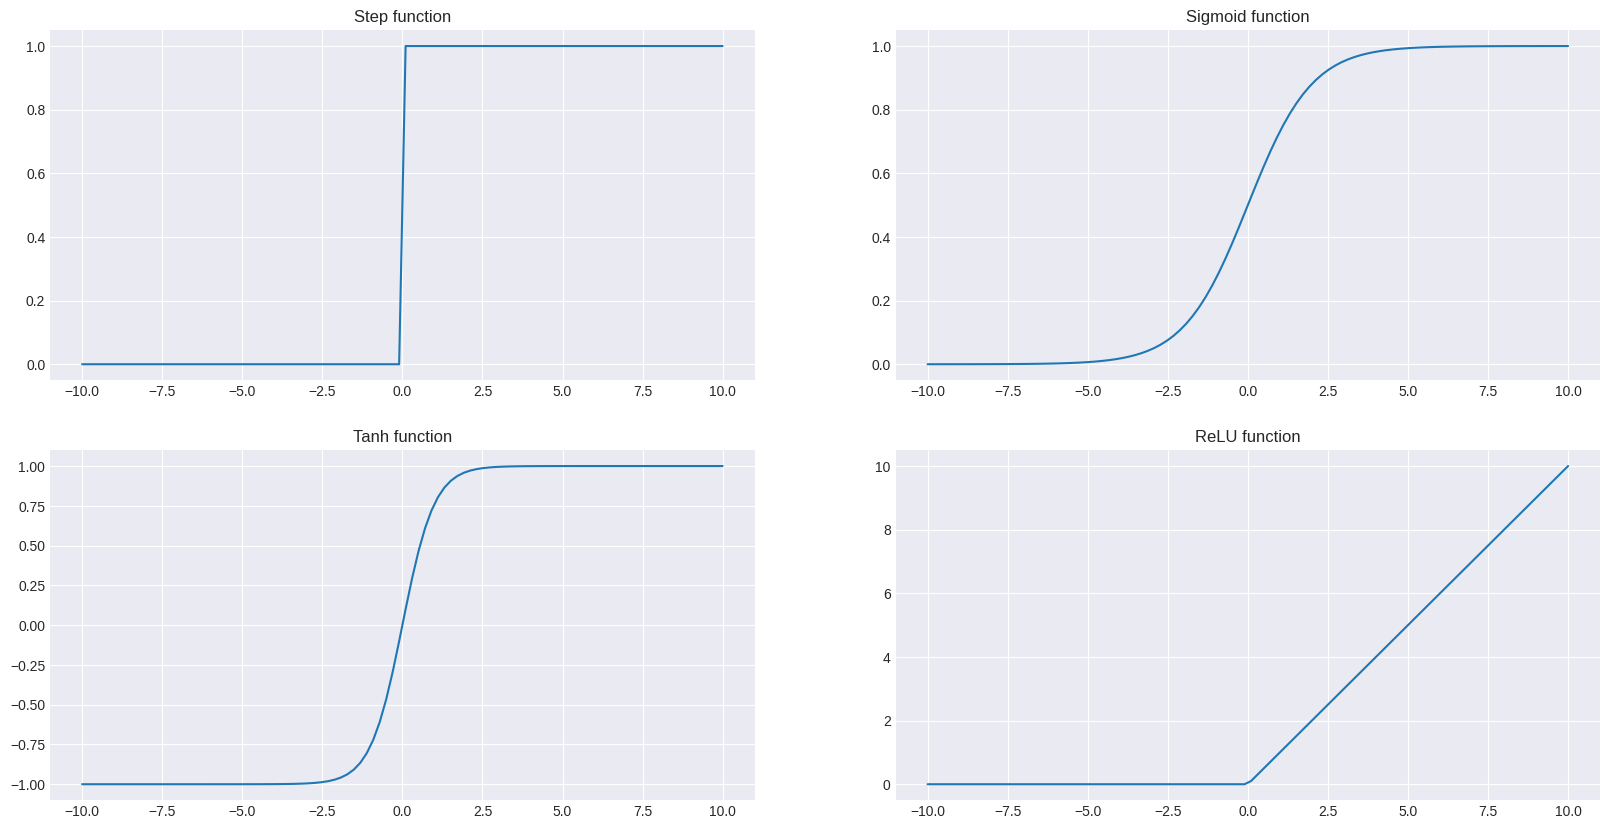

In [3]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')
import numpy as np

sample_x = np.linspace(-10 ,10 , 100)

def step_function(x):
    return (x >= 0) * 1

def sigmoid_function(x):
    return 1/(1 + np.exp(-x))

def tanh(x):
    return np.tanh(x) # Your code here, now is just some zeros

def reLU(x):
    return (x >= 0) * x


fig, axe = plt.subplots(2, 2, figsize=(20,10))


axe[0][0].plot(sample_x, step_function(sample_x))
axe[0][0].set_title("Step function")

axe[0][1].plot(sample_x, sigmoid_function(sample_x))
axe[0][1].set_title("Sigmoid function")

axe[1][0].plot(sample_x, tanh(sample_x))
axe[1][0].set_title("Tanh function")

axe[1][1].plot(sample_x, reLU(sample_x))
axe[1][1].set_title("ReLU function")

pass

`*What is the difference between step function and sigmoid?*`

### 4. More layers

Sometimes we cannot find a solution with only one layer.  For example:

| feature 1     | feature 2     | label |
|:-------------:|:-------------:|:-----:|
|     1         |       1       |   0   |
|     1         |       -1       |   1   |
|     -1         |       1       |   1   |
|     -1         |       -1       |   0   |

This is known as XOR (exclusive OR).  When you try to find a solution using a single layer perceptron, you probably end up seating in front of your computer scratching your head.  Now, we need a more complicated network.

In [ ]:
import pandas as pd
xor_df = pd.DataFrame([
    [True, True],
    [True, False],
    [False, True],
    [False, False],
], columns=["f1", "f2"])

# Layer 1
xor_df['NOT (f1 and f2)'] = ~(xor_df['f1'] & xor_df['f2'])
xor_df['(f1 or f2)'] = xor_df['f1'] | xor_df['f2']

# Layer 2
xor_df['XOR'] = xor_df['NOT (f1 and f2)'] & xor_df['(f1 or f2)']

xor_df

,f1,f2,NOT (f1 and f2),(f1 or f2),XOR
0,True,True,False,True,False
1,True,False,True,True,True
2,False,True,True,True,True
3,False,False,True,False,False


From the pandas dataframe we can see, we need two steps to achieve XOR.
1. Create the result of "NOT (f1 AND f2)", name it as h1
2. Create the result of "f1 OR f2", name it as h2
3. XOR comes from "h1 and h2"

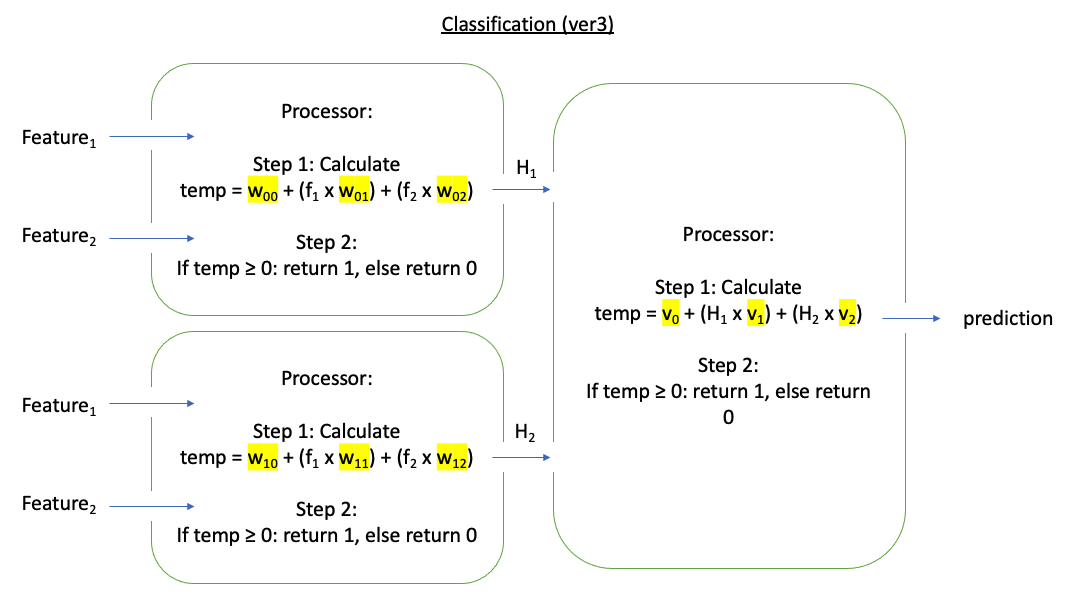

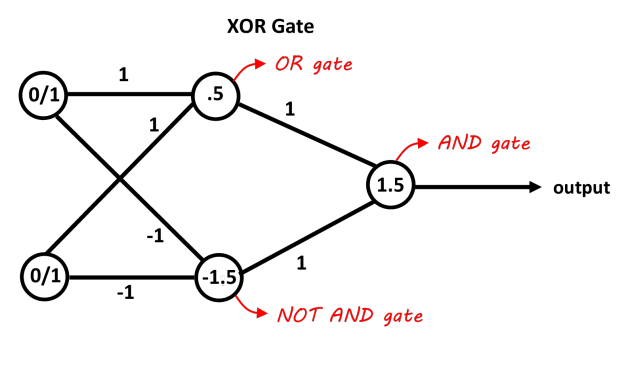

Image credit: https://blog.abhranil.net/2015/03/03/training-neural-networks-with-genetic-algorithms/

### 4. Back propagation: Gradient descent across multiple layers

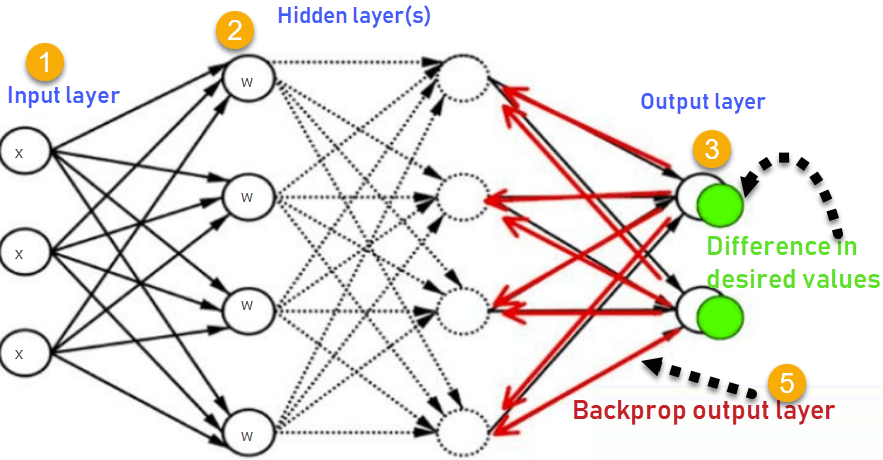

Image credit: https://www.guru99.com/backpropogation-neural-network.html

Recommended reading: https://www.youtube.com/watch?v=tIeHLnjs5U8


### 4. Convolutional

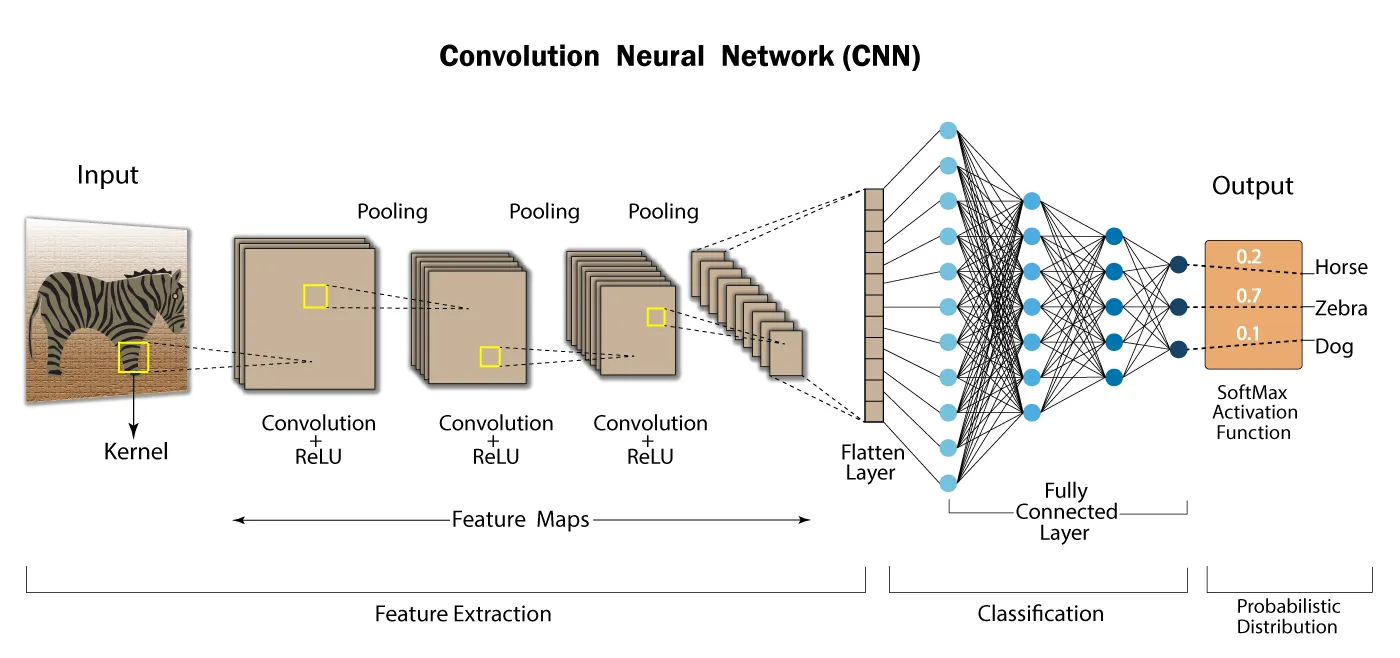

Image credit: https://developersbreach.com/convolution-neural-network-deep-learning/

### 5. Recurrent

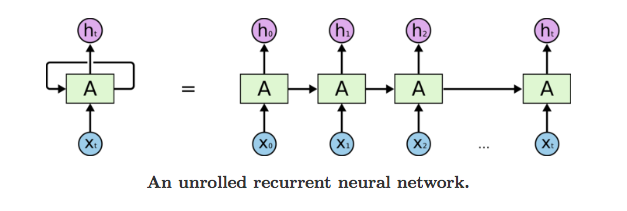

Image credit: https://aditi-mittal.medium.com/understanding-rnn-and-lstm-f7cdf6dfc14e